In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
results = pd.read_csv('../survey/results/results_100_full.csv', index_col=0)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names
full_datasets = results['Task'].unique()

In [3]:
results = results[results['Strategy'] != 'sf_adaptive']

In [4]:
METRIC = 'spearman'
metric_columns = [name for name in column_names if METRIC in name]
initial_columns = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed']
included_columns = [*initial_columns, *metric_columns]
task_results = results[included_columns]
task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_name',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_name'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)
task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)
task_performances = task_performances[(task_performances['mean'] > 0.1)]
intermediate_tasks = task_performances['Task'].to_list()

print(f'Intermediate tasks considered: {len(intermediate_tasks)}')

Intermediate tasks considered: 51


In [5]:
METRIC = 'spearman'
metric_columns = [name for name in column_names if METRIC in name]
initial_columns = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed']
included_columns = [*initial_columns, *metric_columns]
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)
average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)

average_results_agg.head(30)

,Strategy,Sampler,Model,Batch,mean,sem
98,sf,medoids,none,none,0.910974,0.002647
12,al_adaptive,max_entropy,nn,cluster_margin,0.909891,0.002835
4,al_adaptive,max_entropy,gp_ard,cluster_margin,0.903578,0.002676
0,al_adaptive,max_entropy,gp,cluster_margin,0.903569,0.002675
84,al_adaptive,random,nn,cluster_margin,0.902531,0.002994
99,sf,random,none,none,0.900845,0.002682
60,al_adaptive,medoids,nn,cluster_margin,0.899660,0.003079
52,al_adaptive,medoids,gp_ard,cluster_margin,0.898635,0.002818
36,al_adaptive,maximin,nn,cluster_margin,0.895309,0.003104
48,al_adaptive,medoids,gp,cluster_margin,0.895033,0.002926


In [6]:
# Generate figure showing the relative performance of training set selection strategies.
al_counter = 0
plot_data = []
for _, row in average_results_agg.iterrows():
    if 'sf' in row['Strategy']:
        plot_data.append((f'{row["Sampler"]}', row['mean'], row['sem']))
    elif row['Sampler'] == 'medoids' or row['Sampler'] == 'random': #row['Sampler'] != 'maximin' and row['Sampler'] != 'medoids' and row['Sampler'] != 'max_entropy':
        al_counter += 1
        plot_data.append((f'{row["Sampler"]}-{row["Model"]}-{row["Batch"]}', row['mean'], row['sem']))

2


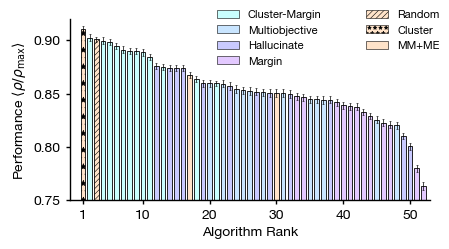

In [7]:
import matplotlib
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['hatch.linewidth'] = 0.4

# Revised color palette.
def get_color(label):

    # Active learning.
    if len(label.split('-')) > 1:
        
        if 'cluster_margin' in label:
            return "#C9FFFE"
        
        elif 'pareto' in label:
            return "#C9E5FF"

        elif 'hallucinate' in label:
            return "#C9CAFF"
        
        elif 'topk' in label:
            return "#E3C9FF"
    
    # Space-filling.
    else:
        return "#FFE3C9"

fig, ax = plt.subplots(1,1,figsize=(4.5, 2.5))

x_locations = [i + 1 for i in range(len(plot_data))]
levels = [datum[1] for datum in plot_data]
colors = [get_color(datum[0]) for datum in plot_data]
random_idx = -1
for idx, datum in enumerate(plot_data):
    if 'random' == datum[0]:
        random_idx = idx
print(random_idx)
errors = [datum[2] for datum in plot_data]
bars = ax.bar(
    x_locations, levels, yerr=errors, color=colors, width=0.7, linewidth=0.6, 
    edgecolor='black', error_kw={'linewidth': 0.5, 'capsize': 0.6, 'capthick': 0.4}
)
bars[random_idx].set_hatch('//////')
bars[random_idx].set_rasterized(False)
bars[0].set_hatch('**')
bars[0].set_rasterized(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C9FFFE', label='Cluster-Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9E5FF', label='Multiobjective', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9CAFF', label='Hallucinate', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#E3C9FF', label='Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='//////', label='Random', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='***', label='Cluster', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', label='MM+ME', edgecolor='black', linewidth=0.4),
]
fig.legend(handles=legend_elements, edgecolor='white', ncol=2, fontsize=8, columnspacing=4.0)

ax.set_xlabel('Algorithm Rank')
ax.tick_params(axis='both', left=True, bottom=True, width=1, length=3.0)
ax.set_xticks([1, 10, 20, 30, 40, 50])
ax.set_xlim(xmin=-1.0, xmax=len(plot_data) + 1)
ax.set_ylim(ymin=0.75, ymax=0.92)
ax.set_ylabel(r'Performance $\langle\rho/\rho_{\text{max}}\rangle$')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./figures/survey_high_d.pdf', dpi=500, transparent=True)
plt.show()